# Data

## Loading the images

In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
from tensorflow.python.client import device_lib

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

['/device:CPU:0', '/device:GPU:0', '/device:GPU:1']


In [2]:
import os
import numpy as np
from keras.models import load_model
from PIL import Image
from matplotlib import pyplot as plt

# Load dataset function
def load_dataset(dataset_dir):
    images = []
    labels = []
    class_names = sorted(os.listdir(dataset_dir))
    class_indices = {class_name: index for index, class_name in enumerate(class_names)}

    for class_name in class_names:
        class_dir = os.path.join(dataset_dir, class_name)
        image_files = os.listdir(class_dir)

        for image_file in image_files:
            image_path = os.path.join(class_dir, image_file)
            image = Image.open(image_path)
            images.append(np.array(image))
            labels.append(class_indices[class_name])

    return images, labels

def visualize_images(images, labels):
    """
    Display a random selection of images from the dataset along with their labels.
    
    Args:
        images (list): List of image data as NumPy arrays.
        labels (list): List of corresponding labels.
    """
    num_images = len(images)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    
    for i, ax in enumerate(axes.flatten()):
        random_index = np.random.randint(num_images)
        image = images[random_index]
        label = labels[random_index]
        
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(label)
    
    plt.tight_layout()
    plt.show()

# Specify the path to your dataset directory
dataset_dir = '/kaggle/input/flower-classification/Data/train'

# Load the dataset
images, labels = load_dataset(dataset_dir)




/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

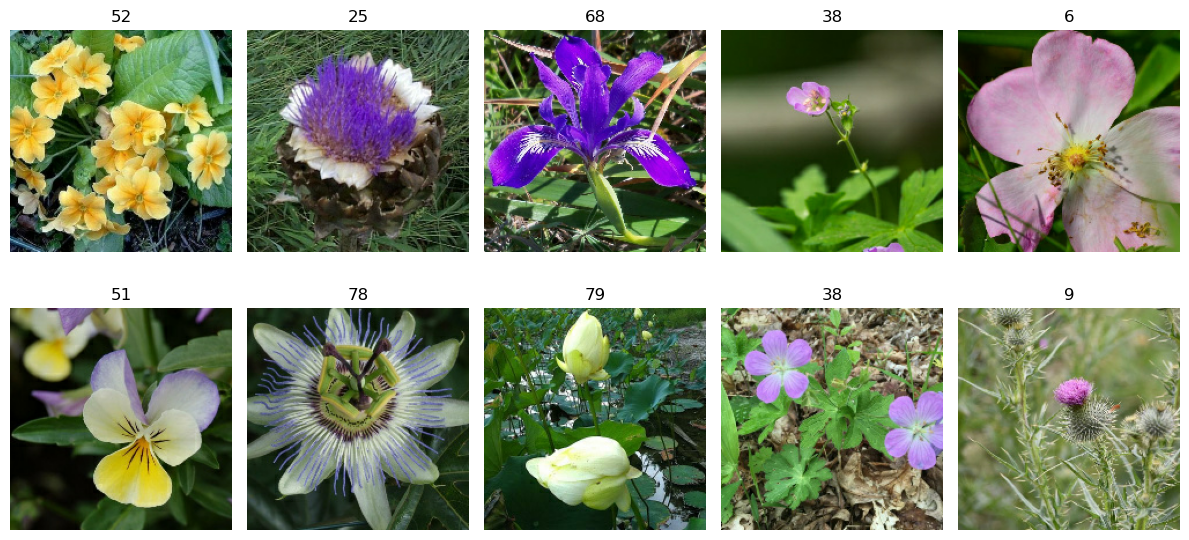

In [2]:
# Visualize some images
visualize_images(images, labels)


In [5]:
# Display class counts
unique_classes, counts = np.unique(labels, return_counts=True)

for class_name, count in zip(unique_classes, counts):
    print(f"Class: {class_name}, Count: {count}")
    


Class: 0, Count: 272
Class: 1, Count: 26
Class: 2, Count: 136
Class: 3, Count: 31
Class: 4, Count: 25
Class: 5, Count: 390
Class: 6, Count: 743
Class: 7, Count: 43
Class: 8, Count: 92
Class: 9, Count: 263
Class: 10, Count: 227
Class: 11, Count: 21
Class: 12, Count: 55
Class: 13, Count: 50
Class: 14, Count: 90
Class: 15, Count: 26
Class: 16, Count: 20
Class: 17, Count: 19
Class: 18, Count: 96
Class: 19, Count: 48
Class: 20, Count: 19
Class: 21, Count: 85
Class: 22, Count: 83
Class: 23, Count: 21
Class: 24, Count: 34
Class: 25, Count: 119
Class: 26, Count: 109
Class: 27, Count: 21
Class: 28, Count: 105
Class: 29, Count: 24
Class: 30, Count: 23
Class: 31, Count: 20
Class: 32, Count: 18
Class: 33, Count: 36
Class: 34, Count: 57
Class: 35, Count: 26
Class: 36, Count: 19
Class: 37, Count: 73
Class: 38, Count: 703
Class: 39, Count: 64
Class: 40, Count: 96
Class: 41, Count: 63
Class: 42, Count: 110
Class: 43, Count: 18
Class: 44, Count: 172
Class: 45, Count: 125
Class: 46, Count: 261
Class: 47

## Splitting The data

In [3]:
#Split the training data into training and validation

train_val_ratio = 0.9
train_val_index = int(len(images) * train_val_ratio)

train_data = images[:train_val_index]
train_labels = labels[:train_val_index]
val_data = images[train_val_index:]
val_labels = labels[train_val_index:]

train_data = np.array(train_data[:train_val_index])
train_labels = np.array(train_labels[:train_val_index])
val_data = np.array(train_data[train_val_index:])
val_labels = np.array(train_labels[train_val_index:])



## Data preprocessing

In [4]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the training labels
train_labels_one_hot = to_categorical(train_labels, num_classes=104)

# One-hot encode the validation labels
val_labels_one_hot = to_categorical(val_labels, num_classes=104)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Scale pixel values between 0 and 1
    rotation_range=20,  # Randomly rotate images by 20 degrees
    width_shift_range=0.2,  # Randomly shift images horizontally by 20% of the width
    height_shift_range=0.2,  # Randomly shift images vertically by 20% of the height
    shear_range=0.2,  # Randomly apply shearing transformations
    zoom_range=0.2,  # Randomly zoom-in on images
    horizontal_flip=True,  # Randomly flip images horizontally
    fill_mode='nearest'  # Fill any newly created pixels during augmentation with the nearest pixel value
)

# No augmentation for validation/test data (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Prepare the augmented training data generator
train_generator = train_datagen.flow(
    train_data, train_labels_one_hot, batch_size=32
)

# Prepare the validation data generator
val_generator = test_datagen.flow(
    val_data, val_labels_one_hot, batch_size=32
)

# Build CNN models

## Simple model of your own

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define the model
model = Sequential()

# Add convolutional layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(192, 192, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Flatten the output
model.add(Flatten())

# Add a fully connected layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(104, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Training Simple Model

In [8]:
# Train the model with the ModelCheckpoint callback
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)
model.save(f'model_simple.h5')

Epoch 1/15


2023-05-27 02:52:36.262014: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


359/359 [==============================] - 113s 279ms/step - loss: 3.8829 - accuracy: 0.1429
Epoch 2/15
359/359 [==============================] - 100s 279ms/step - loss: 3.3039 - accuracy: 0.1901
Epoch 3/15
359/359 [==============================] - 98s 274ms/step - loss: 3.0216 - accuracy: 0.2326
Epoch 4/15
359/359 [==============================] - 98s 274ms/step - loss: 2.8278 - accuracy: 0.2632
Epoch 5/15
359/359 [==============================] - 99s 275ms/step - loss: 2.6654 - accuracy: 0.2988
Epoch 6/15
359/359 [==============================] - 99s 275ms/step - loss: 2.5539 - accuracy: 0.3233
Epoch 7/15
359/359 [==============================] - 99s 276ms/step - loss: 2.4362 - accuracy: 0.3518
Epoch 8/15
359/359 [==============================] - 99s 277ms/step - loss: 2.3433 - accuracy: 0.3747
Epoch 9/15
359/359 [==============================] - 100s 278ms/step - loss: 2.2695 - accuracy: 0.3915
Epoch 10/15
359/359 [==============================] - 99s 275ms/step - loss: 2.2

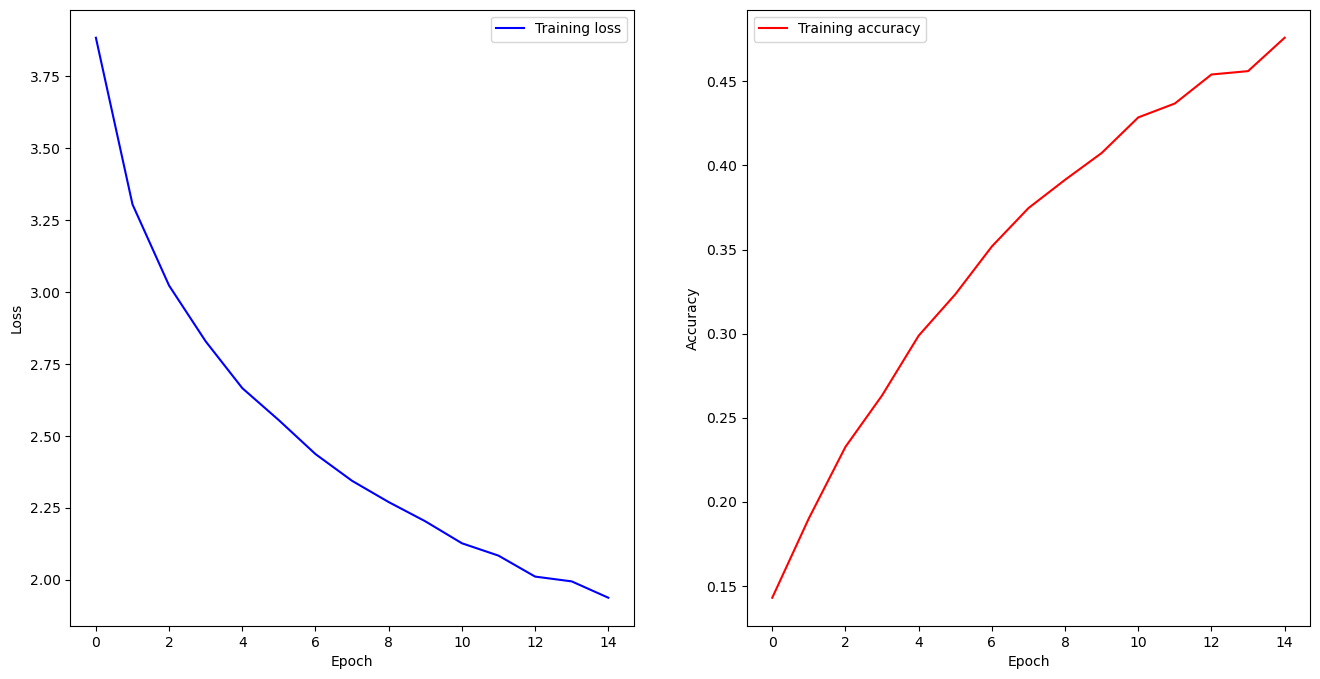

In [9]:
# Plot the loss and accuracy curves
plt.figure(figsize=(16, 8))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='red', label='Training accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## The VGG Model

In [10]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Load the pre-trained VGG16 model
vgg_model = VGG19(weights='imagenet', include_top=False, input_shape=(192, 192, 3))

# Freeze the layers of the pre-trained model
for layer in vgg_model.layers:
    layer.trainable = False

# Add custom fully connected layers on top of the pre-trained model
x = Flatten()(vgg_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(104, activation='softmax')(x)

# Create the final VGG model
model = Model(inputs=vgg_model.input, outputs=x)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

80134624/80134624 [==============================] - 1s 0us/step


### Training VGG Model

In [11]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
model.save(f'model_VGG_.h5')


Epoch 1/10
359/359 [==============================] - 113s 300ms/step - loss: 3.1297 - accuracy: 0.2720
Epoch 2/10
359/359 [==============================] - 105s 291ms/step - loss: 2.2269 - accuracy: 0.4362
Epoch 3/10
359/359 [==============================] - 104s 289ms/step - loss: 1.8999 - accuracy: 0.4983
Epoch 4/10
359/359 [==============================] - 105s 291ms/step - loss: 1.7290 - accuracy: 0.5360
Epoch 5/10
359/359 [==============================] - 104s 289ms/step - loss: 1.6349 - accuracy: 0.5574
Epoch 6/10
359/359 [==============================] - 103s 287ms/step - loss: 1.5723 - accuracy: 0.5732
Epoch 7/10
359/359 [==============================] - 103s 288ms/step - loss: 1.4939 - accuracy: 0.5905
Epoch 8/10
359/359 [==============================] - 104s 289ms/step - loss: 1.4268 - accuracy: 0.6066
Epoch 9/10
359/359 [==============================] - 104s 290ms/step - loss: 1.4096 - accuracy: 0.6089
Epoch 10/10
359/359 [==============================] - 104s 288m

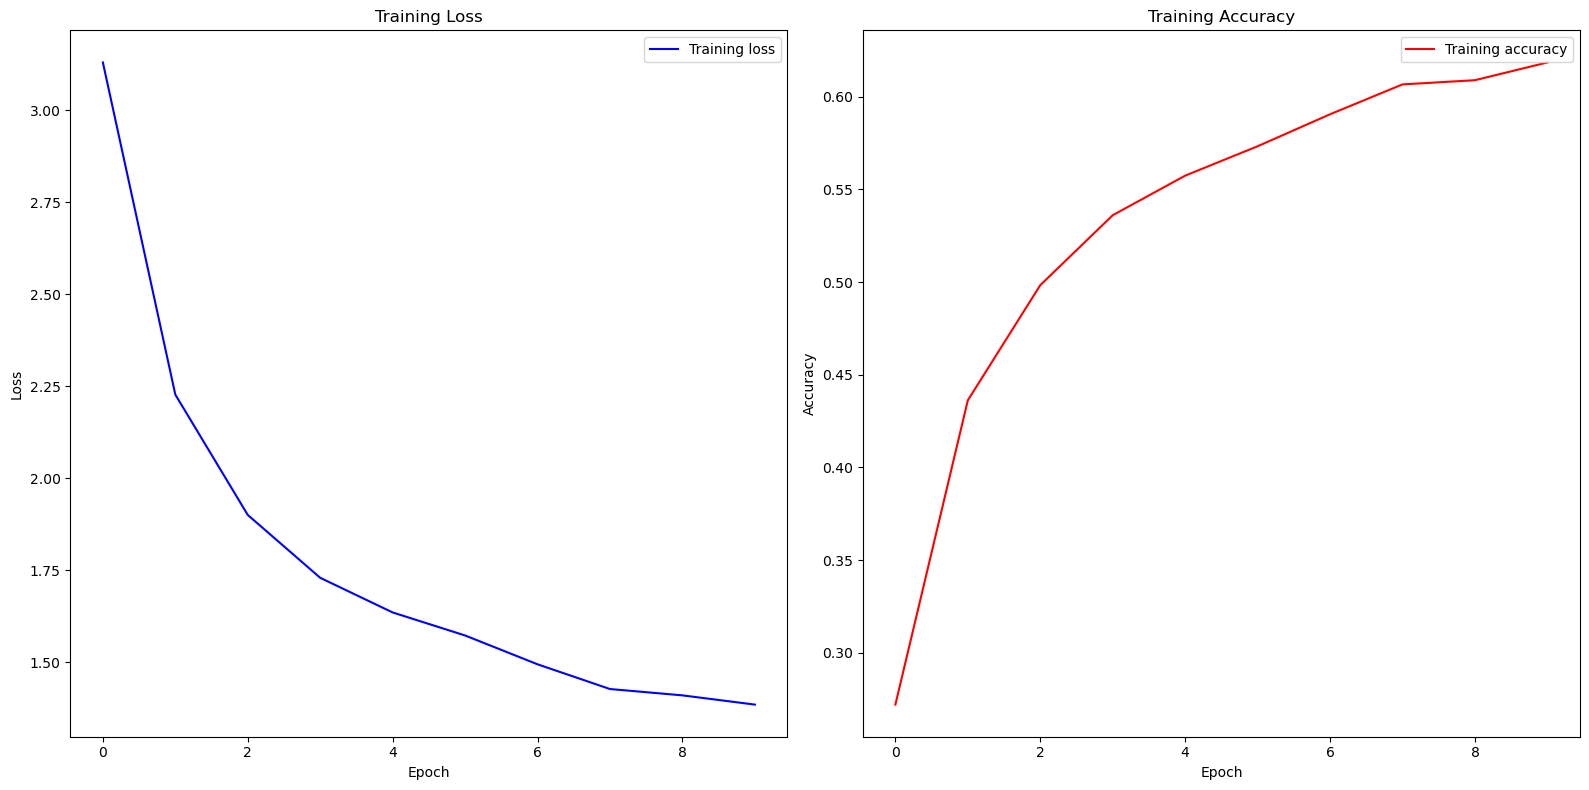

In [13]:
# Plot the loss and accuracy curves
plt.figure(figsize=(16, 8))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='red', label='Training accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()


## ResNet Model

In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense

# Load the pre-trained ResNet50 model
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(192, 192, 3))

# Freeze the layers of the pre-trained model
for layer in resnet_model.layers:
    layer.trainable = False

# Add custom fully connected layers on top of the pre-trained model
x = Flatten()(resnet_model.output)
x = Dense(256, activation='relu')(x)
x = Dense(104, activation='softmax')(x)  # Update the number of units to num_classes

# Create the final ResNet model
model = Model(inputs=resnet_model.input, outputs=x)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 [==============================] - 2s 0us/step


### Training ResNet Model

In [15]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)
model.save(f'model_ResNet.h5')



Epoch 1/10
359/359 [==============================] - 109s 288ms/step - loss: 4.1584 - accuracy: 0.0662
Epoch 2/10
359/359 [==============================] - 101s 280ms/step - loss: 3.9549 - accuracy: 0.0884
Epoch 3/10
359/359 [==============================] - 102s 283ms/step - loss: 3.9001 - accuracy: 0.1005
Epoch 4/10
359/359 [==============================] - 100s 278ms/step - loss: 3.8077 - accuracy: 0.1080
Epoch 5/10
359/359 [==============================] - 100s 279ms/step - loss: 3.7436 - accuracy: 0.1187
Epoch 6/10
359/359 [==============================] - 102s 284ms/step - loss: 3.7153 - accuracy: 0.1215
Epoch 7/10
359/359 [==============================] - 101s 282ms/step - loss: 3.6853 - accuracy: 0.1192
Epoch 8/10
359/359 [==============================] - 102s 283ms/step - loss: 3.6815 - accuracy: 0.1263
Epoch 9/10
359/359 [==============================] - 101s 281ms/step - loss: 3.6288 - accuracy: 0.1309
Epoch 10/10
359/359 [==============================] - 101s 281m

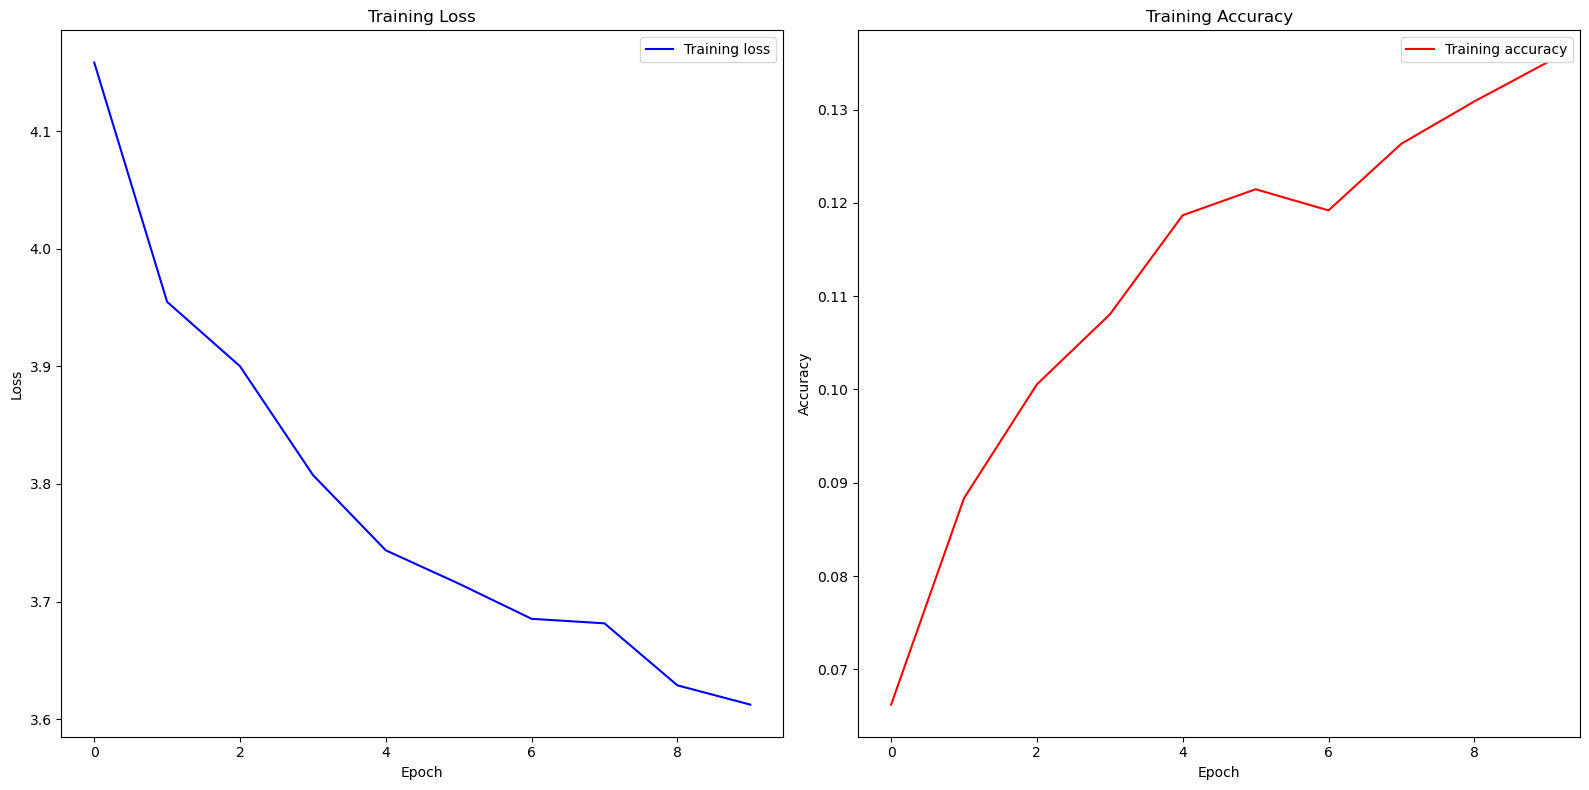

In [16]:
# Plot the loss and accuracy curves
plt.figure(figsize=(16, 8))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='blue', label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='red', label='Training accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()


## Ensemple

### Loading test data and ensemple function

In [4]:
# Ensemble prediction function
def ensemble_predictions(models, X):
    predictions = np.zeros((len(X), len(models)))
    for i, model in enumerate(models):
        predictions[:, i] = np.argmax(model.predict(X), axis=-1)
    ensemble_preds = np.apply_along_axis(lambda x: np.bincount(x.astype(int)).argmax(), axis=1, arr=predictions)
    return ensemble_preds
# Load the test dataset
test_data_dir = '/kaggle/input/flower-classification/Data/test'  # Replace with the actual path to the test dataset directory
test_data, test_labels = load_dataset(test_data_dir)

# Convert the test data and labels to NumPy arrays
test_data = np.array(test_data)
test_labels = np.array(test_labels)

### Loading the models

In [5]:
# Load the trained models
model_1 = load_model('model_simple.h5')
model_2 = load_model('model_VGG_.h5')
model_3 = load_model('model_ResNet.h5')


models = [model_1, model_2, model_3]

# Evaluate ensemble on test data
ensemble_preds = ensemble_predictions(models, test_data)
accuracy = np.sum(ensemble_preds == test_labels) / len(test_labels)
print('Ensemble accuracy:', accuracy)

116/116 [==============================] - 9s 61ms/step
Ensemble accuracy: 0.12176724137931035


# Big Picture

## Plotting the models Accuracies


In [6]:
from keras.utils import to_categorical

num_classes = 104
test_labels_one_hot = to_categorical(test_labels, num_classes)

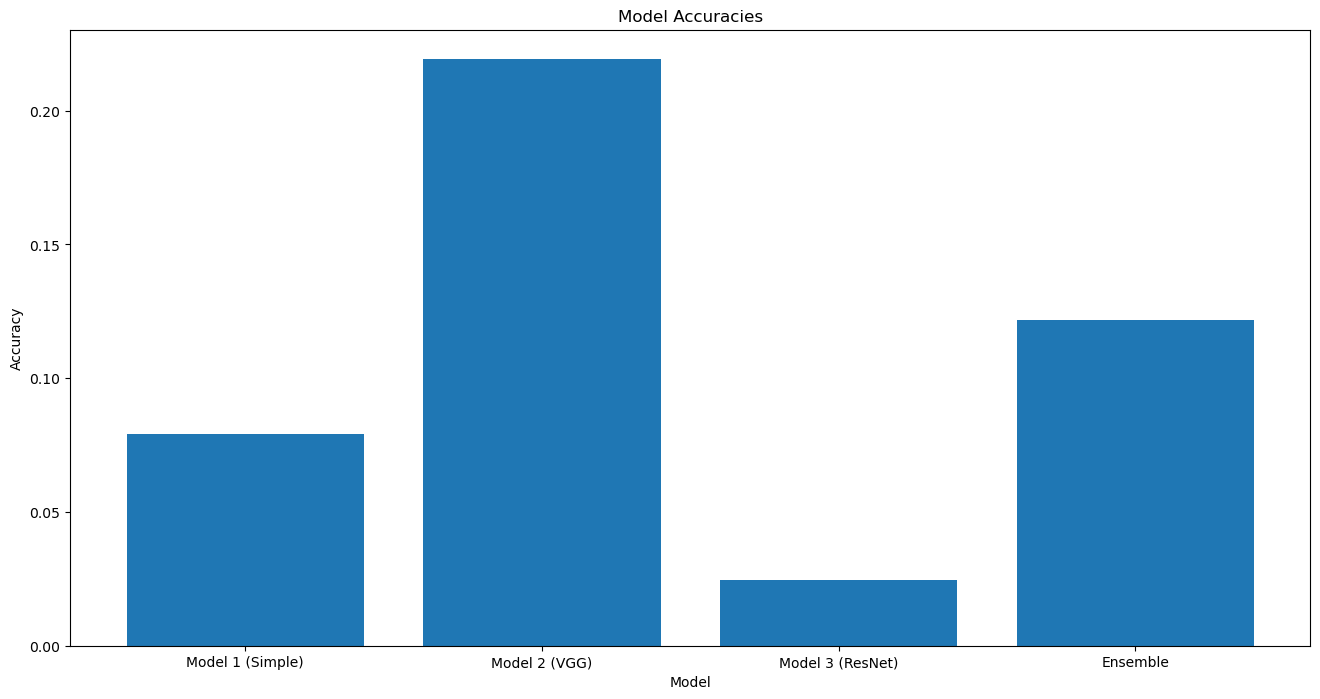

In [8]:
# Plot the accuracy
model_names = ['Model 1 (Simple)', 'Model 2 (VGG)', 'Model 3 (ResNet)', 'Ensemble']
accuracies = []

for model in models:
    model_accuracy = model.evaluate(test_data, test_labels_one_hot, verbose=0)[1]
    accuracies.append(model_accuracy)

accuracies.append(accuracy)

plt.figure(figsize=(16, 8))
plt.bar(model_names, accuracies)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracies')
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# Assuming you already have the models and test data loaded
models = [model_1, model_2, model_3]
model_names = ['Model 1 (Simple)', 'Model 2 (VGG)', 'Model 3 (ResNet)']

# Compute predictions for each model
predictions = [np.argmax(model.predict(test_data), axis=-1) for model in models]

# Compute accuracy and Macro F-Score for each model
accuracies = [accuracy_score(test_labels, preds) for preds in predictions]
f_scores = [f1_score(test_labels, preds, average='macro') for preds in predictions]

# Print accuracy and Macro F-Score
for i, (acc, f_score) in enumerate(zip(accuracies, f_scores)):
    print(f"{model_names[i]}: Accuracy = {acc:.4f}, Macro F-Score = {f_score:.4f}")

116/116 [==============================] - 8s 66ms/step
Model 1 (Simple): Accuracy = 0.0792, Macro F-Score = 0.0235
Model 2 (VGG): Accuracy = 0.2193, Macro F-Score = 0.1563
Model 3 (ResNet): Accuracy = 0.0245, Macro F-Score = 0.0016


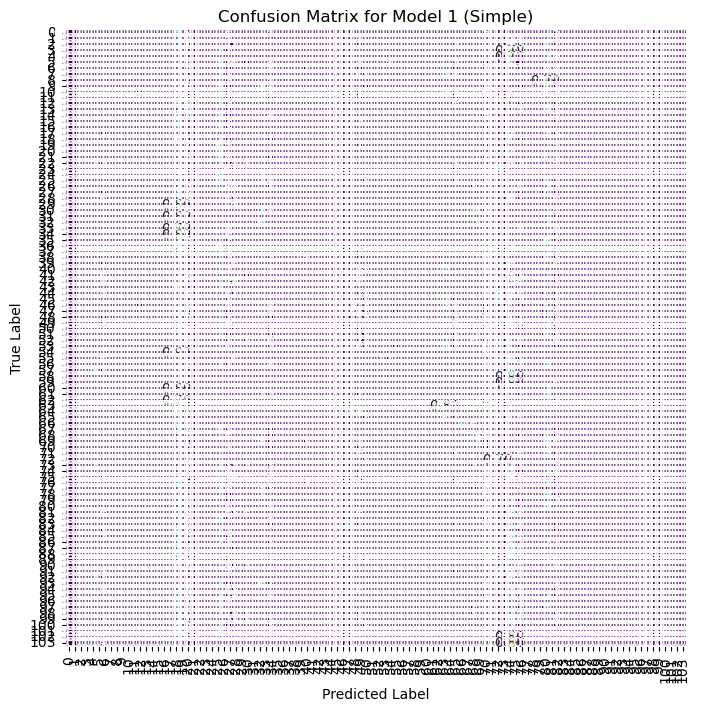

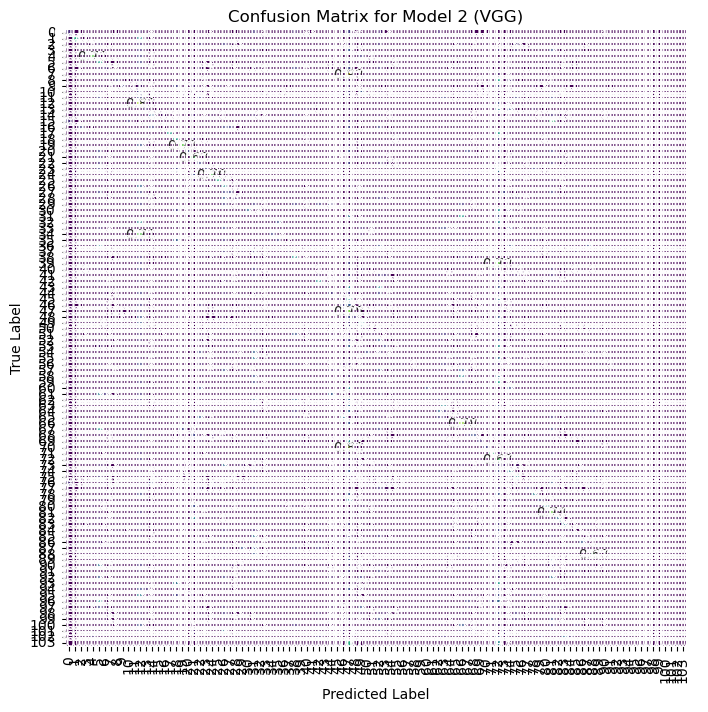

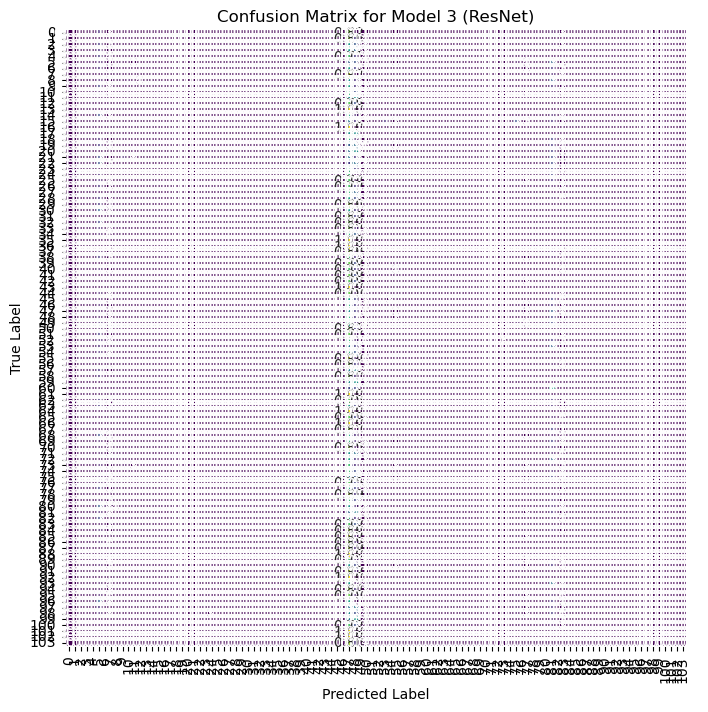

Model 1 (Simple): Most confusing classes = (6, 80)
Model 2 (VGG): Most confusing classes = (53, 72)
Model 3 (ResNet): Most confusing classes = (38, 47)


In [10]:
# Compute and plot confusion matrices
for i, (model_name, preds) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(test_labels, preds)
    normalized_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8, 8))
    sns.heatmap(normalized_cm, annot=True, cmap='viridis', cbar=False,
                xticklabels=True, yticklabels=True, fmt='.2f')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Find the most confusing classes
for i, (model_name, preds) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(test_labels, preds)
    np.fill_diagonal(cm, 0)
    most_confusing_classes = np.unravel_index(cm.argmax(), cm.shape)
    print(f"{model_name}: Most confusing classes = {most_confusing_classes}")

In [ ]:
import seaborn as sn

# Compute and plot confusion matrices
for i, (model_name, preds) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(test_labels, preds)
    normalized_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 7))
    sn.set(font_scale=1.4)  # for label size
    ax = sn.heatmap(normalized_cm, annot=True, cmap='viridis', cbar=False,
                    xticklabels=True, yticklabels=True, fmt='.2f', annot_kws={"size": 16})
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Find the most confusing classes
for i, (model_name, preds) in enumerate(zip(model_names, predictions)):
    cm = confusion_matrix(test_labels, preds)
    np.fill_diagonal(cm, 0)
    most_confusing_classes = np.unravel_index(cm.argmax(), cm.shape)
    print(f"{model_name}: Most confusing classes = {most_confusing_classes}")